In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy as stats
import sklearn
from sklearn.preprocessing import FunctionTransformer


In [2]:
df =  pd.read_csv("Loan_Default.csv")

## Step 1: Train/Test split of Data

In [3]:
from sklearn.model_selection import train_test_split

X = df.drop(columns = ['Status'])
y = df['Status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size = 0.2,
    random_state = 42,
    stratify = y # preserves default/non-default ratio in both sets
)

print(X_train.shape)
print(X_test.shape)



(118936, 33)
(29734, 33)


## Step 2: Data Cleaning

In [4]:
# Step 1 — write a plain function
def lowercase_columns(X, y=None):
    X = X.copy()

    # lowercase column names
    X.columns = X.columns.str.lower()

    # lowercase values inside column object
    object_col = X.select_dtypes(include = 'object').columns
    for col in object_col:
        X[col] = X[col].str.lower()
    return X

# Step 2 — wrap it in FunctionTransformer
lowercase_step = FunctionTransformer(lowercase_columns)

In [5]:
# Decided at training time, hardcoded into the pipeline after investigation
# Reason: 100% MNAR for Status=1 in training data → confirmed leakage
# Reassess if data collection process changes upstream
def dropcol(X, y=None):
    X = X.copy()
    X.drop(columns= ['interest_rate_spread', 'credit_type', 'ltv','upfront_charges','rate_of_interest','property_value'] , inplace = True, errors='ignore') # derived from loan_amount and income, high VIF

    return X

IRScase_step = FunctionTransformer(dropcol)

## Step 3: Handling missing data

In [6]:
# Handling missing number
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.compose import ColumnTransformer

# Column groups for imputation
mnar_num_cols_with_flag = ['income']

mnar_num_cols_without_flag = ['dtir1']

mnar_cat_cols_without_flag = ['age', 'submission_of_application']

mcar_cols = ['loan_limit', 'neg_ammortization', 'loan_purpose', 'term','approv_in_adv']



imputer = ColumnTransformer(
            transformers = [
                ('mnar_num_with_flag', SimpleImputer(strategy = 'median', add_indicator = True), mnar_num_cols_with_flag),
                ('mnar_num_without_flag', SimpleImputer(strategy = 'median', add_indicator = False), mnar_num_cols_without_flag),
                ('mnar_cat_without_flag', SimpleImputer(strategy = 'most_frequent', add_indicator = False), mnar_cat_cols_without_flag),
                ('mcar', SimpleImputer(strategy = 'most_frequent'),mcar_cols)
            ], remainder='passthrough', verbose_feature_names_out=False
).set_output(transform='pandas')

## Step 4: Feature Engineering

In [7]:
# Feature engineering: Applying tranformation on skewed data and group rare labels
from sklearn.preprocessing import PowerTransformer

yeo_cols = ['income', 'loan_amount', 'term']
yeo_step = ColumnTransformer(
           transformers = [('yeo', PowerTransformer(method = 'yeo-johnson'), yeo_cols)
        ], remainder = 'passthrough', verbose_feature_names_out=False
).set_output(transform = 'pandas')


#High interest rate segment flag.
# A model without the flag has to figure out this sharp boundary on its own from the data. 
# A model with the flag already knows — "this loan belongs to a fundamentally different segment.
#def add_high_ir_flag(X, y=None):
#    X = X.copy()
#    X['high_ir_segment'] = (X['rate_of_interest'] > 5.5).astype(int)
#    return X

#high_ir_step = FunctionTransformer(add_high_ir_flag)

In [8]:
#Rare label segment
rare_label_mapping = {
    'open_credit'       : {'opc': 'other'},
    'total_units'       : {'2u': 'multi_unit', '3u': 'multi_unit', '4u': 'multi_unit'}
}

def group_rare_labels(X, y=None):
    X = X.copy()
    for col, mapping in rare_label_mapping.items():
        if col in X.columns:
            X[col] = X[col].replace(mapping)
    return X

rare_label_step = FunctionTransformer(group_rare_labels)

## Step 5: Feature Selection

In [9]:
cols_to_drop_s4 = [
    'id',                      # non-predictive identifier
    'year',                    # non-predictive identifier                    
    'business_or_commercial',  # high collinearity with loan_type, weaker predictor
    'construction_type',       # high collinearity with security_type, negligible signal
    'secured_by',              # Cramer's V = 0.98 with security_type
]

def drop_features(X,y=None):
    X = X.copy()
    cols = [cols for cols in cols_to_drop_s4 if cols in X.columns]
    X.drop(columns = cols, inplace = True)
    return X

feature_selection_step = FunctionTransformer(drop_features)

## Step 6: Encoding

In [10]:
from sklearn.preprocessing import OrdinalEncoder, OneHotEncoder

# age categories in correct order — low to high
age_order = ['<25', '25-34', '35-44', '45-54', '55-64', '65-74', '>74']

ordinal_cols = ['age']

# remaining object columns after drops
ohe_cols = [
    'loan_limit', 'approv_in_adv', 'loan_type', 'loan_purpose',
    'neg_ammortization', 'interest_only', 'lump_sum_payment',
    'open_credit', 'total_units', 'security_type',
    'submission_of_application', 'region', 'gender',
    'co-applicant_credit_type', 'occupancy_type','credit_worthiness'
]

encoder = ColumnTransformer(
            transformers = [
                ('ordinal', OrdinalEncoder(categories = [age_order], 
                                           handle_unknown = 'use_encoded_value', 
                                           unknown_value = -1), 
                ordinal_cols),
                ('ohe', OneHotEncoder(
                        handle_unknown = 'ignore',
                        sparse_output = False,
                        drop = 'first'
                ), ohe_cols),
            ],
            remainder = 'passthrough', verbose_feature_names_out=False 
).set_output(transform = 'pandas')


encoding_step = encoder                       

## Step 7: Scaling

In [11]:
from sklearn.pipeline import Pipeline

pipeline = Pipeline([
    ('lowercase', lowercase_step),
    ('drop_cols', IRScase_step),
    ('imputer', imputer),
    ('rare_labels', rare_label_step),
    ('yeo', yeo_step),
    ('feature_selection', feature_selection_step),
    ('encoding', encoding_step),
    ##('scaling', scaler_step)
])

X_transformed = pipeline.fit_transform(X_train)

In [12]:
scale_cols = [
    'income',            # yeo-johnson transformed
    'loan_amount',       # yeo-johnson transformed
    'term',              # yeo-johnson transformed
    'dtir1',             # continuous numerical
    'credit_score',      # continuous numerical
]

numeric_check = X_transformed[scale_cols]

# Skewness after transformation
skew_after = numeric_check.skew().round(3)

outlier_summary = []
for col in scale_cols:
    Q1 = numeric_check[col].quantile(0.25)
    Q3 = numeric_check[col].quantile(0.75)
    IQR = Q3 - Q1
    upper = Q3 + 1.5*IQR
    lower = Q1 - 1.5*IQR
    outlier_count = ((numeric_check[col] < lower) | (numeric_check[col] > upper)).sum()
    outlier_pct = round((outlier_count / len(numeric_check) * 100), 2)

    outlier_summary.append({
        'column' : col,
        'skew_after' : skew_after[col],
        'outlier_count' : outlier_count,
        'outlier_pct' : outlier_pct
    })

result = pd.DataFrame(outlier_summary).sort_values('outlier_pct', ascending = False)

print(result)

         column  skew_after  outlier_count  outlier_pct
2          term      -1.727          21593        18.16
3         dtir1      -0.663           4411         3.71
0        income       0.493           3790         3.19
1   loan_amount      -0.008            499         0.42
4  credit_score       0.004              0         0.00


In [13]:
from sklearn.preprocessing import StandardScaler, RobustScaler

standard_cols = [
    'income',            # yeo-johnson transformed
    'loan_amount',       # yeo-johnson transformed
    'dtir1',             # continuous numerical
    'credit_score',      # continuous numerical
]

robust_cols = [
    'term',              # yeo-johnson transformed
]



scaler = ColumnTransformer(
    transformers = [
        ('standard_scaler', StandardScaler(), standard_cols),
        ('robust_scaler', RobustScaler(), robust_cols),
    ],
    remainder = 'passthrough',
    verbose_feature_names_out = False,
).set_output(transform = 'pandas')

scaler_step = scaler

In [14]:
pipeline = Pipeline([
    ('lowercase', lowercase_step),
    ('drop_cols', IRScase_step),
    ('imputer', imputer),
    ('rare_labels', rare_label_step),
    ('yeo', yeo_step),
    ('feature_selection', feature_selection_step),
    ('encoding', encoding_step),
    ('scaling', scaler_step)
])

X_transformed = pipeline.fit_transform(X_train)
print(X_transformed.shape)
print(f"Missing_value : {X_transformed.isnull().sum().sum()}")  # should be 0

(118936, 31)
Missing_value : 0


In [15]:
print("Class distribution in y_train:")
print(y_train.value_counts())
print()
print(y_train.value_counts(normalize=True).round(3) * 100)

majority = y_train.value_counts().max()
minority = y_train.value_counts().min()
ratio = round(majority / minority,1)
ratio

Class distribution in y_train:
Status
0    89625
1    29311
Name: count, dtype: int64

Status
0    75.4
1    24.6
Name: proportion, dtype: float64


3.1

## Step 8: Model training

In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_validate
from xgboost import XGBClassifier

#------Cross-validation strategy---------
cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

#––––––––––––––––Scoring metrics–––––––––––––––––––––––––

scoring = {
    'roc_auc' : 'roc_auc',
    'pr_auc' : 'average_precision'
}

# ── Models ───────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(
                                class_weight='balanced',
                                max_iter=1000,
                                random_state=42
                            ),
    'XGBoost'             : XGBClassifier(
                                scale_pos_weight=89625/29311,
                                random_state=42,
                                eval_metric='auc',
                                verbosity=0        # suppress xgboost logs
                            ),
}

In [17]:
def cast_indicators_to_float(X):
    indicator_cols = [c for c in X.columns if 'missingindicator' in c.lower()]
    X = X.copy()
    X[indicator_cols] = X[indicator_cols].astype(float)
    return X

cast_step = FunctionTransformer(cast_indicators_to_float)

In [18]:
results = []

for model_name, model in models.items():
    
    # Create full pipeline — preprocessing + model
    full_pipeline = Pipeline([
        ('lowercase',         lowercase_step),
        ('drop_cols',         IRScase_step),
        ('imputer',           imputer),
        ('cast_float',        cast_step),  
        ('rare_labels',       rare_label_step),
        ('yeo',               yeo_step),
        ('feature_selection', feature_selection_step),
        ('encoding',          encoding_step),
        ('scaling',           scaler_step),
        ('model',             model)
    ])
    
    # Cross validate
    cv_results = cross_validate(
        full_pipeline,
        X_train,          # raw unprocessed X_train
        y_train,
        cv=cv,
        scoring=scoring,
        return_train_score=False
    )
    
    # Store results
    results.append({
        'model'           : model_name,
        'roc_auc_mean'    : cv_results['test_roc_auc'].mean().round(4),
        'roc_auc_std'     : cv_results['test_roc_auc'].std().round(4),
        'pr_auc_mean'     : cv_results['test_pr_auc'].mean().round(4),
        'pr_auc_std'      : cv_results['test_pr_auc'].std().round(4),
    })
    
    print(f"{model_name} done.")

# Display results
results_df = pd.DataFrame(results).sort_values('roc_auc_mean', ascending=False)
print(results_df)

Logistic Regression done.
XGBoost done.
                 model  roc_auc_mean  roc_auc_std  pr_auc_mean  pr_auc_std
1              XGBoost        0.8663       0.0032       0.7845      0.0038
0  Logistic Regression        0.7536       0.0030       0.5538      0.0025


In [19]:
full_pipeline = Pipeline([
        ('lowercase',         lowercase_step),
        ('drop_cols',         IRScase_step),
        ('imputer',           imputer),
        ('cast_float',        cast_step),
        ('rare_labels',       rare_label_step),
        ('yeo',               yeo_step),
        ('feature_selection', feature_selection_step),
        ('encoding',          encoding_step),
        ('scaling',           scaler_step),
        ('model',             model)
    ])

full_pipeline.fit(X_train, y_train)

# Get transformed feature names and importances
xgb_model = full_pipeline.named_steps['model']

# Get transformed data directly
X_transformed = full_pipeline[:-1].transform(X_train)

# Get feature names from transformed dataframe
# Since you have .set_output(transform='pandas'), column names are preserved
feature_names = X_transformed.columns.tolist()

# Get importances
xgb_model = full_pipeline.named_steps['model']

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

                              feature  importance
30            missingindicator_income    0.336219
15          lump_sum_payment_not_lpsm    0.112623
2                               dtir1    0.071862
26       co-applicant_credit_type_exp    0.063814
13          neg_ammortization_not_neg    0.056042
19  submission_of_application_to_inst    0.044375
29               credit_worthiness_l2    0.037105
8                     loan_type_type2    0.036936
9                     loan_type_type3    0.029957
12                    loan_purpose_p4    0.023911
23                       gender_joint    0.019595
14              interest_only_not_int    0.016960
6                      loan_limit_ncf    0.016802
7                   approv_in_adv_pre    0.015456
0                              income    0.012723
16                  open_credit_other    0.010666
27                  occupancy_type_pr    0.009949
11                    loan_purpose_p3    0.008835
17             total_units_multi_unit    0.008105


## Observation:
- rate_of_interest missingness perfectly predicts target
- creating an indicator flag for it is leakage
- move it to mnar_num_cols without indicator

In [20]:
print(pd.crosstab(
    X_train['age'].isna(),
    y_train,
    normalize='index'
).round(3))

print(pd.crosstab(
    X_train['rate_of_interest'].isna(),
    y_train,
    normalize='index'
).round(3))

print(pd.crosstab(
    X_train['submission_of_application'].isna(),
    y_train,
    normalize='index'
).round(3))

mnar_check = ['Upfront_charges', 'property_value', 'dtir1', 'income']

for col in mnar_check:
    print(f"\n{col}:")
    print(pd.crosstab(
        X_train[col].isna(),
        y_train,
        normalize='index'
    ).round(3))

Status      0      1
age                 
False   0.755  0.245
True    0.000  1.000
Status                0      1
rate_of_interest              
False             0.998  0.002
True              0.000  1.000
Status                         0      1
submission_of_application              
False                      0.755  0.245
True                       0.000  1.000

Upfront_charges:
Status               0      1
Upfront_charges              
False            0.999  0.001
True             0.080  0.920

property_value:
Status              0      1
property_value              
False           0.838  0.162
True            0.000  1.000

dtir1:
Status      0      1
dtir1               
False   0.836  0.164
True    0.326  0.674

income:
Status      0      1
income              
False   0.746  0.254
True    0.863  0.137


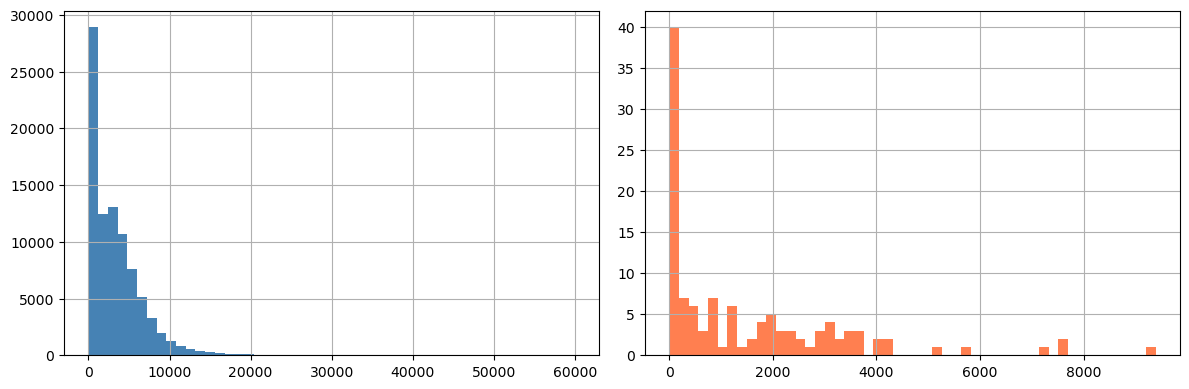

Upfront charges = 0 for defaulters:
39

Upfront charges missing for defaulters:
29195

Upfront charges missing for non-defaulters:
2525


In [21]:
import matplotlib.pyplot as plt

# Compare upfront_charges distribution for defaulters vs non-defaulters
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

X_train_copy = X_train.copy()
X_train_copy['Status'] = y_train.values

X_train_copy[X_train_copy['Status']==0]['Upfront_charges'].hist(
    bins=50, ax=axes[0], color='steelblue')

X_train_copy[X_train_copy['Status']==1]['Upfront_charges'].hist(
    bins=50, ax=axes[1], color='coral')

plt.tight_layout()
plt.show()

# Check how many defaulters have upfront_charges = 0 or NaN
print("Upfront charges = 0 for defaulters:")
print((X_train_copy[X_train_copy['Status']==1]['Upfront_charges'] == 0).sum())

print("\nUpfront charges missing for defaulters:")
print(X_train_copy[X_train_copy['Status']==1]['Upfront_charges'].isna().sum())

print("\nUpfront charges missing for non-defaulters:")
print(X_train_copy[X_train_copy['Status']==0]['Upfront_charges'].isna().sum())

In [22]:
# Check if upfront_charges = 0 tells a different story than missing
X_train_copy = X_train.copy()
X_train_copy['Status'] = y_train.values

# Distribution of non-missing upfront charges by default status
print("Non-missing upfront_charges stats by Status:")
print(X_train_copy.groupby('Status')['Upfront_charges'].describe().round(2))

# Check loan_type distribution for defaulters vs non-defaulters
# to see if it's a product difference
print("\nloan_type distribution for defaulters:")
print(X_train_copy[X_train_copy['Status']==1]['loan_type'].value_counts(normalize=True).round(3))

print("\nloan_type distribution for non-defaulters:")
print(X_train_copy[X_train_copy['Status']==0]['loan_type'].value_counts(normalize=True).round(3))

Non-missing upfront_charges stats by Status:
          count     mean      std  min     25%      50%      75%       max
Status                                                                    
0       87100.0  3223.61  3243.13  0.0  574.55  2605.06  4809.42  60000.00
1         116.0  1488.48  1862.95  0.0    0.00   825.68  2339.82   9387.07

loan_type distribution for defaulters:
loan_type
type1    0.704
type2    0.195
type3    0.101
Name: proportion, dtype: float64

loan_type distribution for non-defaulters:
loan_type
type1    0.780
type2    0.121
type3    0.099
Name: proportion, dtype: float64


In [23]:
y_train.value_counts()

Status
0    89625
1    29311
Name: count, dtype: int64

In [24]:
X_train['Upfront_charges'].isnull().value_counts()

Upfront_charges
False    87216
True     31720
Name: count, dtype: int64

In [25]:
print("count or % of rate_of_interest missing for defaulters:")
print(X_train_copy[X_train_copy['Status']==1]['rate_of_interest'].isna().sum())
print(f"Pct: {X_train_copy[X_train_copy['Status']==1]['rate_of_interest'].isna().mean()*100:.1f}%")

print("\nrate_of_interest missing for non-defaulters:")
print(X_train_copy[X_train_copy['Status']==0]['rate_of_interest'].isna().sum())
print(f"Pct: {X_train_copy[X_train_copy['Status']==0]['rate_of_interest'].isna().mean()*100:.1f}%")

# Also check non-missing value distribution
print("\nNon-missing rate_of_interest stats by Status:")
print(X_train_copy.groupby('Status')['rate_of_interest'].describe().round(3))

count or % of rate_of_interest missing for defaulters:
29155
Pct: 99.5%

rate_of_interest missing for non-defaulters:
0
Pct: 0.0%

Non-missing rate_of_interest stats by Status:
          count   mean    std    min    25%    50%    75%  max
Status                                                        
0       89625.0  4.044  0.562  0.000  3.625  3.990  4.375  8.0
1         156.0  4.359  0.479  3.375  3.990  4.375  4.750  5.5


In [26]:
# property_value
print("property_value missing for defaulters:")
print(X_train_copy[X_train_copy['Status']==1]['property_value'].isna().sum())
print(f"Pct: {X_train_copy[X_train_copy['Status']==1]['property_value'].isna().mean()*100:.1f}%")

print("\nproperty_value missing for non-defaulters:")
print(X_train_copy[X_train_copy['Status']==0]['property_value'].isna().sum())
print(f"Pct: {X_train_copy[X_train_copy['Status']==0]['property_value'].isna().mean()*100:.1f}%")

# dtir1 and income flags
for col in ['dtir1', 'income']:
    print(f"\n{col} missingness vs target:")
    print(pd.crosstab(
        X_train_copy[col].isna(),
        y_train,
        normalize='index'
    ).round(3))

property_value missing for defaulters:
12000
Pct: 40.9%

property_value missing for non-defaulters:
1
Pct: 0.0%

dtir1 missingness vs target:
Status      0      1
dtir1               
False   0.836  0.164
True    0.326  0.674

income missingness vs target:
Status      0      1
income              
False   0.746  0.254
True    0.863  0.137


In [27]:
# How many rows have dtir1 missing?
print("dtir1 missing counts:")
print(f"Defaulters    : {X_train_copy[X_train_copy['Status']==1]['dtir1'].isna().sum()}")
print(f"Non-defaulters: {X_train_copy[X_train_copy['Status']==0]['dtir1'].isna().sum()}")
print(f"Defaulter missing pct : {X_train_copy[X_train_copy['Status']==1]['dtir1'].isna().mean()*100:.1f}%")
print(f"Non-defaulter missing pct: {X_train_copy[X_train_copy['Status']==0]['dtir1'].isna().mean()*100:.1f}%")

# How many rows have income missing?
print("\nincome missing counts:")
print(f"Defaulters    : {X_train_copy[X_train_copy['Status']==1]['income'].isna().sum()}")
print(f"Non-defaulters: {X_train_copy[X_train_copy['Status']==0]['income'].isna().sum()}")
print(f"Defaulter missing pct : {X_train_copy[X_train_copy['Status']==1]['income'].isna().mean()*100:.1f}%")
print(f"Non-defaulter missing pct: {X_train_copy[X_train_copy['Status']==0]['income'].isna().mean()*100:.1f}%")

dtir1 missing counts:
Defaulters    : 12985
Non-defaulters: 6269
Defaulter missing pct : 44.3%
Non-defaulter missing pct: 7.0%

income missing counts:
Defaulters    : 1004
Non-defaulters: 6351
Defaulter missing pct : 3.4%
Non-defaulter missing pct: 7.1%


In [28]:
print("dtir1 non-missing stats by Status:")
print(X_train_copy.groupby('Status')['dtir1'].describe().round(3))

dtir1 non-missing stats by Status:
          count    mean     std  min   25%   50%   75%   max
Status                                                      
0       83356.0  37.373  10.028  5.0  31.0  38.0  44.0  61.0
1       16326.0  39.625  12.708  5.0  32.0  42.0  49.0  61.0


=== Final Test Set Evaluation ===

ROC-AUC : 0.8756
PR-AUC  : 0.8002

Classification Report:
              precision    recall  f1-score   support

  No Default       0.90      0.90      0.90     22406
     Default       0.69      0.71      0.70      7328

    accuracy                           0.85     29734
   macro avg       0.80      0.80      0.80     29734
weighted avg       0.85      0.85      0.85     29734

Confusion Matrix:
[[20120  2286]
 [ 2144  5184]]


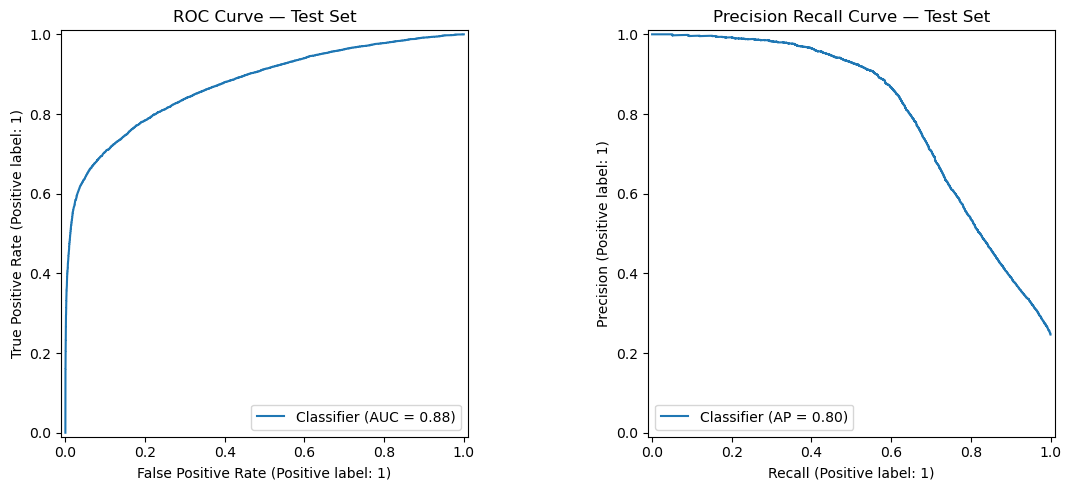

In [29]:
from sklearn.metrics import (roc_auc_score, average_precision_score,
                             classification_report, confusion_matrix,
                             RocCurveDisplay, PrecisionRecallDisplay)
import matplotlib.pyplot as plt

# Fit best model on full training set
best_pipeline = Pipeline([
    ('preprocessing', pipeline),
    ('model', XGBClassifier(
                scale_pos_weight=89625/29311,
                random_state=42,
                eval_metric='auc',
                verbosity=0
             ))
])

best_pipeline.fit(X_train, y_train)

# Predict on test set — used only once
y_pred_proba = best_pipeline.predict_proba(X_test)[:, 1]
y_pred       = best_pipeline.predict(X_test)

# Scores
print("=== Final Test Set Evaluation ===\n")
print(f"ROC-AUC : {roc_auc_score(y_test, y_pred_proba):.4f}")
print(f"PR-AUC  : {average_precision_score(y_test, y_pred_proba):.4f}")
print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['No Default', 'Default']))

# Confusion matrix
print("Confusion Matrix:")
confusion_matrix = confusion_matrix(y_test, y_pred)
print(confusion_matrix)

# Plots
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
RocCurveDisplay.from_predictions(y_test, y_pred_proba, ax=axes[0])
axes[0].set_title('ROC Curve — Test Set')

PrecisionRecallDisplay.from_predictions(y_test, y_pred_proba, ax=axes[1])
axes[1].set_title('Precision Recall Curve — Test Set')

plt.tight_layout()
plt.show()

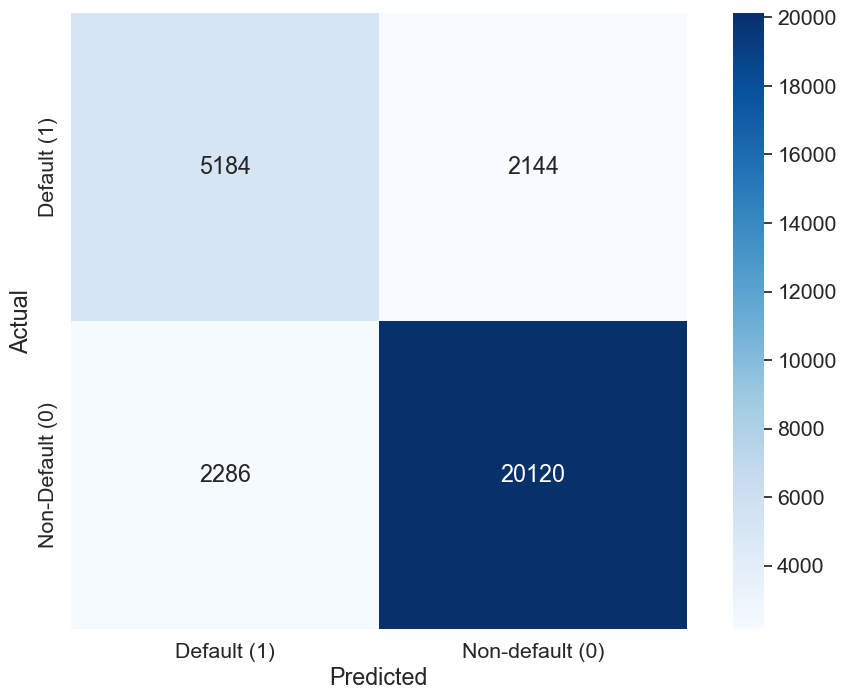

In [30]:
plt.figure(figsize = (12,8))
sns.set(font_scale=1.4)
ax = sns.heatmap(confusion_matrix, cmap='Blues',annot=True, fmt='d', square=True,xticklabels=['Non-default (0)', 'Default (1)'], yticklabels=['Non-Default (0)', 'Default (1)'])
ax.set(xlabel='Predicted', ylabel='Actual')
ax.invert_yaxis()
ax.invert_xaxis()